###  Using classical digitized filters

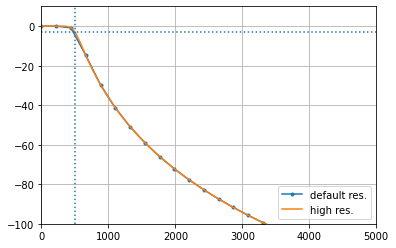

In [155]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 44100
fc = 500
order = 6

# Butterworth low-pass filter
b, a = signal.butter(
    order,
    fc,
    btype='lowpass',
    fs=fs
)

ds = signal.dlti(b, a,  dt=1/fs)
w, gain, phase = ds.bode()
plt.plot(w/2/np.pi, gain, '.-', label='default res.')
# the same with higher resolution
w, gain, phase = ds.bode(w=1000)
plt.plot(w/2/np.pi, gain, label='high res.')
plt.axhline(-3, linestyle=':')
plt.axvline(fc, linestyle=':')
plt.xlim([0, 5000])
plt.ylim([-100, 10])
plt.grid()
plt.legend()

(-100.0, 10.0)

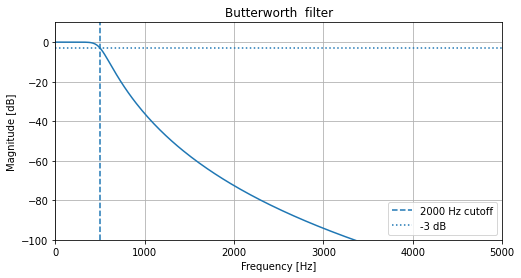

In [156]:
# Frequency response 
w, h = signal.freqz(b, a, worN=1000, fs=fs)
plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-12)))
plt.axvline(fc, linestyle='--', label='2000 Hz cutoff')
plt.axhline(-3.0103, linestyle=':', label='-3 dB')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Butterworth  filter")
plt.grid(True)
plt.legend()
plt.xlim([0, 5000])
plt.ylim([-100, 10])

In [157]:
from scipy.io import wavfile
import scipy.io
fs, data = wavfile.read("02. School Boy-9.wav")
print(fs, data.shape)
print(data[:,0])
print(data.min(), data.max())

44100 (882000, 2)
[-534 -509 -938 ...  837 -211 -897]
-31884 31674


(0.0, 5000.0)

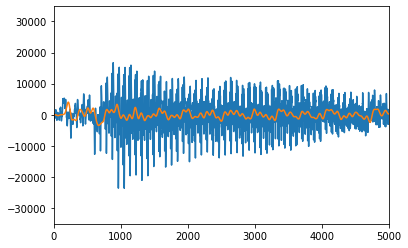

In [158]:
x = data[:, 0]
plt.plot(x)
y = signal.lfilter(b, a, x)
plt.plot(y)
plt.xlim([0,5000])

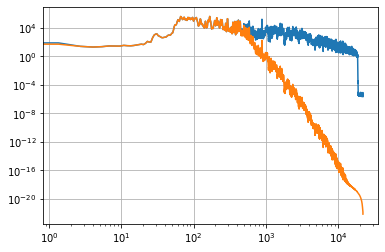

In [159]:
f, sx = signal.welch(
    x,
    fs=fs,
    window="hann",
    nperseg=2**15,
    noverlap=2**14,
    detrend="constant",
    scaling="density"
)
f, sy = signal.welch(
    y,
    fs=fs,
    window="hann",
    nperseg=2**15,
    noverlap=2**14,
    detrend="constant",
    scaling="density"
)
plt.loglog(f, sx)
plt.loglog(f, sy)
plt.grid()
#plt.xlim([0, 250])
#plt.ylim([10**(-5), 10**(7)])

In [160]:
data_filtered = signal.lfilter(b, a, data, axis=0)
data_filtered /= np.max(np.abs(data_filtered))
# normalize safely to int16 range

stereo_int16 = np.int16(data_filtered * 32767)
print(stereo_int16)
wavfile.write("output_filtered.wav", fs, stereo_int16)

[[   0    0]
 [   0    0]
 [   0    0]
 ...
 [4714 6756]
 [4698 6713]
 [4679 6664]]


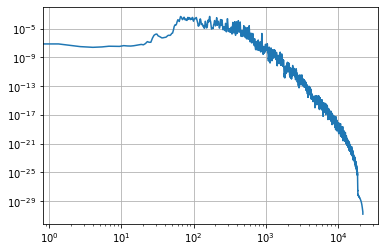

In [154]:
f, sy = signal.welch(
    data_filtered[:,0],
    fs=fs,
    window="hann",
    nperseg=2**15,
    noverlap=2**14,
    detrend="constant",
    scaling="density"
)
plt.loglog(f, sy)
plt.grid()

In [136]:
from pylab import *
from scipy import signal
fs, fl, N = 44100, 500, 251
n = arange(N) - N//2 + 1e-12 # tiny shift so that we don't get 0/0
b_l = sin(2*pi*n*fl/fs)/(n/pi)
w = signal.windows.hann(N)
b_l *= w
b_l /= b_l.sum() # Ensure that the gain at 0Hz is 1. 

ds = signal.dlti(b_l, [1], dt=1/fs)

In [137]:
data_filtered = signal.lfilter(b_l, [1], data, axis=0)
data_filtered /= np.max(np.abs(data_filtered))

stereo_int16 = np.int16(data_filtered * 32767)
print(stereo_int16)
wavfile.write("output_filtered.wav", fs, stereo_int16)

[[   0    0]
 [   0    0]
 [   0    0]
 ...
 [2483 4321]
 [2537 4397]
 [2590 4472]]


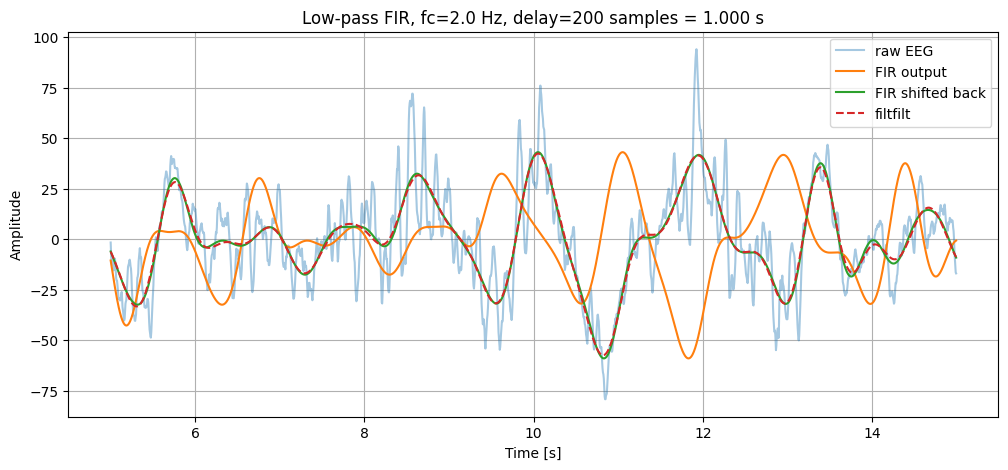

In [11]:
# Demonstrate the phase delay introduced by FIR filters
# and fixing it by forward-backward filtering using 'signal.filtfilt'
from pylab import *
from scipy import signal

# Load EEG
fs = 200.0
x = fromfile("eeg.bin", dtype=float32)

# FIR low-pass design
fc = 2.0
fc = 2.0
numtaps = 401              # odd length
delay = (numtaps - 1) // 2 # samples

b = signal.firwin(
    numtaps,
    fc,
    fs=fs,
    window="hamming",
    pass_zero="lowpass"
)

# FIR band-pass design
#fc = [9,15]
#numtaps = 401              # odd length
#delay = (numtaps - 1) // 2 # samples

#b = signal.firwin(
#    numtaps,
#    fc,
#    fs=fs,
#    window="hamming",
#    pass_zero="bandpass"
#)

# Causal (forward) FIR filtering: introduces linear phase delay 
y = signal.lfilter(b, 1, x)

# Delay-compensated version
y_aligned = roll(y, -delay)
y_aligned[-delay:] = nan

# Zero-phase reference: forward-backward filtering
y_zero = signal.filtfilt(b, 1, x)

# Time axis
t = arange(len(x)) / fs

# Plot a short segment
i0 = 1000
i1 = int(15 * fs)

figure(figsize=(12, 5))
plot(t[i0:i1], x[i0:i1], alpha=0.4, label="raw EEG")
plot(t[i0:i1], y[i0:i1], label="FIR output")
plot(t[i0:i1], y_aligned[i0:i1], label="FIR shifted back")
plot(t[i0:i1], y_zero[i0:i1], "--", label="filtfilt")
xlabel("Time [s]")
ylabel("Amplitude")
title(f"Low-pass FIR, fc={fc} Hz, delay={delay} samples = {delay/fs:.3f} s")
legend()
grid()
show()